# Lynx-Hare-Plant Model 
## Scenario 2 : Extinction of lynxes within 1 year + Stabilizatin of plants and hares within 10 years

In [2]:
# Different required imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

*These are the different imports required in python in order to plot, solve the differential equation initial value problem.*

In [3]:
def plants_hare_lynx(t, y, a1, a2, b1, b2, d1, d2):
    """Plants-hare-lynx three-species model.

    A system of three coupled differential equations modelling the 
    interactions between plants, hares, and lynx.
   
    """
    dydt = np.zeros(3)
    dydt[0] = y[0] * (1 - y[0]) - ((a1 * y[0]) / (1 + b1 * y[0])) * y[1]
    dydt[1] = ((a1 * y[0]) / (1 + b1 * y[0])) * y[1] - d1 * y[1] - (a2 * y[1] / (1 + b2 * y[1])) * y[2]
    dydt[2] = (a2 * y[1] / (1 + b2 * y[1])) * y[2] - d2 * y[2]
    return dydt

*This is the code, provided in the task, which gives us the equations for the dynamics beteween these three populations.* 

In order to try and find a model for such a scenario, we start from the model provided in the book : Modeling life. 
In the book we find the following parameters a1 = 5, b1 = 3, a2 = 0.1, b2 = 2, d1 = 0.4, and d2 = 0.01, and we observe that the initial populations are about 0.8, 0.2, and 8 for carnivores, herbivores, and plants (in our case : lynx, hare and plant) respectively. 

We then adapt the death rate and their efficiency catching hares, more specifically we **increase** the death rate (d2) **from 0.01 to 0.1** and **decrease** how "full" they get (b2) **from 2 to 1**. 

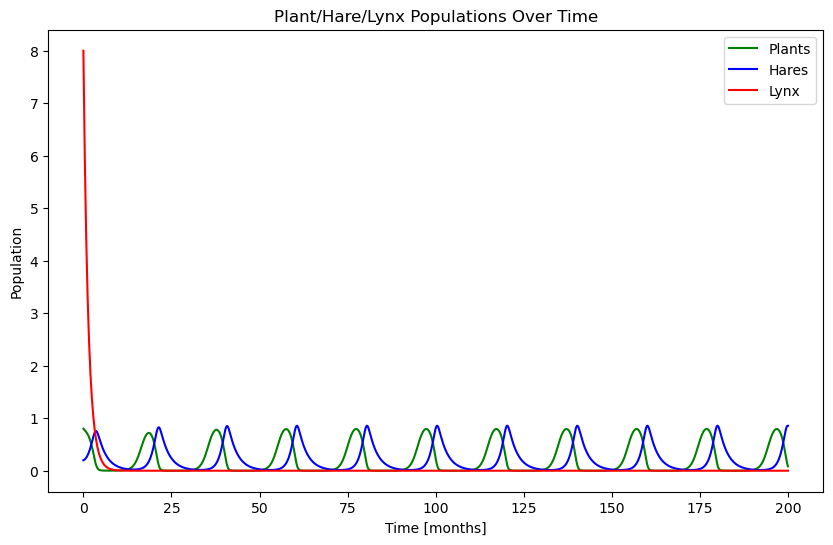

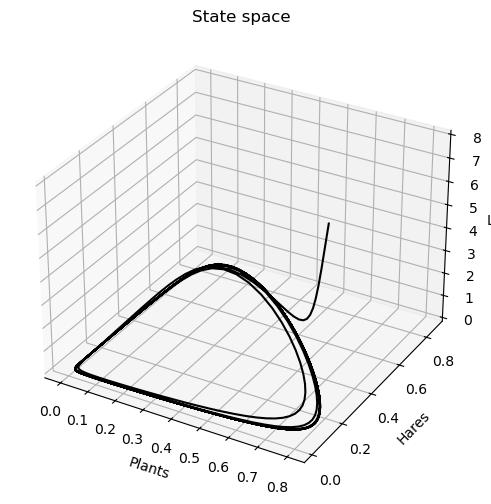

In [4]:
#setting up time as given in the task 
t0 = 0                    # start time of simulation [in months]
tfinal = 200              # end time of simulation [in months]     
tspan = (t0, tfinal)      # time span

#initial conditions at t0 : 
y0 = [0.8, 0.2, 8] # [plants, hares, lynx] at t=0

# Adding parameters 
a1, a2 = 5.0, 0.1
b1, b2 = 3, 1
d1, d2 = 0.4, 0.1 

# The system of ODEs is solved numerically
t_eval = np.linspace(t0, tfinal, 1000)
sol = solve_ivp(lambda t, y: plants_hare_lynx(t, y, a1, a2, b1, b2, d1, d2), 
                tspan, y0, t_eval=t_eval, method='RK23')

# Plot population over time
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sol.t, sol.y[0], label='Plants', color='green')
ax.plot(sol.t, sol.y[1], label='Hares', color='blue')
ax.plot(sol.t, sol.y[2], label='Lynx', color='red')
ax.set_title('Plant/Hare/Lynx Populations Over Time')
ax.set_xlabel('Time [months]')
ax.set_ylabel('Population')
ax.legend(loc='upper right')
plt.show()

# Plot state space (Updated to 3D for three species)

fig2 = plt.figure(figsize=(8, 6))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.plot(sol.y[0], sol.y[1], sol.y[2], color='black')
ax2.set_title('State space')
ax2.set_xlabel('Plants')
ax2.set_ylabel('Hares')
ax2.set_zlabel('Lynx')
plt.show()

From the following plots we observe that the lynx population seems to go exctinct in about 6 months which is within the timeframe of 1 year. We notice from the state space that the population of plants and hares does then seem to stabilize : from the population over time graph we see that this happens pretty much immediatly. 